# DGBISN — Simulation Notebook

**Companion notebook to *DGBISN: A Decentralised Global Blockchain Interbank Settlement Network*.**

This notebook reproduces every quantitative result and every simulation figure in the paper, in the order they appear:

| Section | Paper reference | What it produces |
|---|---|---|
| 1 | — | Setup, 3-colour palette (#1B3B6F, #3E8989, #333333) |
| 2 | §3.3 | Synthetic dataset generation (writes 2 CSV files) |
| 3 | Table 3.1 | Raw data sample |
| 4 | §3.6, Table 3.2 | Preprocessing pipeline (forward-fill → min-max → FX log returns) |
| 5 | Figure 3.1 | Four-layer reference architecture diagram |
| 6 | Figure 3.2 | UML component diagram |
| 7 | Figure 3.3 | Methodology flowchart |
| 8 | Figure 4.1 | 8-node network topology |
| 9 | §3.7.3, §4.2, Figure 4.2 | DSG governance simulation (Properties 1 & 2) |
| 10 | §3.7.4, §4.3, Figure 4.3 | Liquidity equilibrium simulation (Properties 3 & 4) |
| 11 | §4.4, Figure 4.4 | LSTM flow forecasting |
| 12 | §5.1, Figure 5.1 | Comparison with existing systems |
| 13 | §4.5, Figure 4.5 | STRIDE threat mapping |

## Requirements

```
python >= 3.10
numpy, pandas, matplotlib, scikit-learn, torch
```

Install with:
```bash
pip install numpy pandas matplotlib scikit-learn torch
```

## How to run

Execute the cells top-to-bottom. Every result is deterministic given the fixed seed (`SEED = 42`). Outputs are:

* CSV files: `synthetic_flows.csv`, `synthetic_nodes.csv`
* Figure files: `./figures/fig_*.png`


## 1  Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

# ---- The paper's fixed 3-colour palette --------------------------------
PRIMARY   = "#1B3B6F"   # deep blue: governance / settlement primitives
SECONDARY = "#3E8989"   # teal:      value and forecasting services
CHAR      = "#333333"   # charcoal:  text and neutrals

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'axes.edgecolor': CHAR,
    'axes.labelcolor': CHAR,
    'axes.labelsize': 15,
    'axes.titlesize': 18,
    'xtick.color': CHAR,
    'ytick.color': CHAR,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'figure.titlesize': 19,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
})

SEED = 42
np.random.seed(SEED)

FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

print('Setup complete. Palette:', PRIMARY, SECONDARY, CHAR)

Setup complete. Palette: #1B3B6F #3E8989 #333333


## 2  Synthetic dataset generation (§3.3)

Two CSV files are generated:

**`synthetic_flows.csv`** — inter-node settlement flow data. Columns:

* `Day` — 1 to 200
* `Pair` — directed pair, e.g. `A->B`
* `Gross_flow` — daily gross settlement value in raw GST units (with ~2% missing values to demonstrate the imputation step of §3.6)
* `Net_flow` — net directional flow
* `FX_rate` — mid-market exchange rate for the pair

The generator embeds three realistic patterns: a **7-day business-cycle** (Mon–Fri high, weekend low), a slow **network-growth trend**, and per-pair random walks in the FX state.

**`synthetic_nodes.csv`** — node exogenous parameters used by the DSG governance formula. Columns:

* `Node_ID` — A through H
* `GDP_share` — participant share of total GDP (ε_i)
* `Tenure_years` — years since joining the network (raw, before normalisation to τ_i)

In [2]:
def generate_flows_csv(path='synthetic_flows.csv', n_nodes=8, n_days=200, seed=42):
    rng = np.random.default_rng(seed)
    node_labels = [chr(ord('A') + i) for i in range(n_nodes)]
    pairs = [f"{a}->{b}" for a in node_labels for b in node_labels if a != b]

    # Business-day seasonality: Mon-Fri high, weekends low
    dow_factor = np.array([1.0, 1.05, 1.10, 1.05, 1.0, 0.55, 0.45])
    # Slow trend (network growth)
    trend = 1.0 + 0.001 * np.arange(n_days)

    records = []
    fx_state = {p: 1.0 + rng.normal(0, 0.15) for p in pairs}
    flow_base = {p: rng.gamma(3.0, 25.0) for p in pairs}
    net_drift = {p: rng.normal(0, 3) for p in pairs}

    for day in range(1, n_days + 1):
        dow = (day - 1) % 7
        seasonal = dow_factor[dow] * trend[day - 1]
        for p in pairs:
            base = flow_base[p] * seasonal
            spike = 3.0 if rng.random() < 0.02 else 1.0
            gross = max(base * spike + rng.normal(0, 5), 1.0)
            net = net_drift[p] * seasonal + rng.normal(0, base * 0.10)
            fx_state[p] *= np.exp(rng.normal(0, 0.005))
            fx = fx_state[p]
            if rng.random() < 0.02:
                gross = np.nan
            records.append({
                'Day': day,
                'Pair': p,
                'Gross_flow': round(gross, 3) if not np.isnan(gross) else np.nan,
                'Net_flow': round(net, 3),
                'FX_rate': round(fx, 5),
            })
    df = pd.DataFrame(records)
    df.to_csv(path, index=False)
    return df


def generate_nodes_csv(path='synthetic_nodes.csv', n_nodes=8, seed=42):
    rng = np.random.default_rng(seed + 1)
    node_labels = [chr(ord('A') + i) for i in range(n_nodes)]
    raw = rng.pareto(1.5, size=n_nodes) + 0.5
    gdp = raw / raw.sum()
    tenure = rng.integers(1, 12, size=n_nodes)
    df = pd.DataFrame({
        'Node_ID': node_labels,
        'GDP_share': gdp.round(4),
        'Tenure_years': tenure,
    })
    df.to_csv(path, index=False)
    return df


flows = generate_flows_csv(seed=SEED)
nodes = generate_nodes_csv(seed=SEED)
print(f'Wrote synthetic_flows.csv  ({flows.shape[0]:,} rows, {flows.shape[1]} columns)')
print(f'Wrote synthetic_nodes.csv  ({nodes.shape[0]} rows, {nodes.shape[1]} columns)')
print(f'Missing gross-flow rows (to be imputed): {flows["Gross_flow"].isna().sum()}')

Wrote synthetic_flows.csv  (11,200 rows, 5 columns)
Wrote synthetic_nodes.csv  (8 rows, 3 columns)
Missing gross-flow rows (to be imputed): 234


### Node parameters

In [3]:
nodes

,Node_ID,GDP_share,Tenure_years
0,A,0.0679,4
1,B,0.0615,5
2,C,0.0590,8
3,D,0.1886,5
4,E,0.2552,2
5,F,0.0891,11
6,G,0.2144,5
7,H,0.0643,10


## 3  Raw data inspection (Table 3.1)

The first eight rows of the raw data reproduce the shape of Table 3.1 in the paper.

In [4]:
flows.head(8)

,Day,Pair,Gross_flow,Net_flow,FX_rate
0,1,A->B,57.194,13.641,1.05557
1,1,A->C,29.881,-2.320,0.84534
2,1,A->D,15.591,-6.015,1.11166
3,1,A->E,84.589,-2.555,1.13609
4,1,A->F,92.786,19.953,0.70281
5,1,A->G,67.945,-9.935,0.80319
6,1,A->H,103.252,-6.487,1.02314
7,1,B->A,26.302,-3.191,0.95143


## 4  Preprocessing pipeline (§3.6, Table 3.2)

Three steps, applied per pair:

1. **Missing-value imputation** — directional forward-fill along the time axis, with a maximum gap of 3 consecutive days.
2. **Min–max normalisation** — gross and net flows scaled to the unit interval on a per-pair basis; the sign of net flows is preserved by scaling the absolute value and re-applying the sign.
3. **FX log returns** — raw FX-rate levels are converted to log returns $r_t = \log(\mathrm{FX}_t / \mathrm{FX}_{t-1})$ to enforce stationarity for the LSTM in §4.4.

Outlier trimming is deliberately **not** applied at the preprocessing stage — extreme flow events are one of the phenomena the AI layer is meant to detect.

In [5]:
def preprocess(df, max_gap=3):
    out = df.copy().sort_values(['Pair', 'Day']).reset_index(drop=True)
    out['Imputed'] = out['Gross_flow'].isna()

    # (i) forward-fill
    out['Gross_flow'] = out.groupby('Pair')['Gross_flow'].ffill(limit=max_gap)
    out = out.dropna(subset=['Gross_flow']).reset_index(drop=True)

    # (ii) min-max per pair
    def _norm_pos(x):
        lo, hi = x.min(), x.max()
        return (x - lo) / (hi - lo) if hi > lo else x * 0

    def _norm_signed(x):
        hi = np.abs(x).max()
        return x / hi if hi > 0 else x

    out['Gross_norm'] = out.groupby('Pair')['Gross_flow'].transform(_norm_pos)
    out['Net_norm']   = out.groupby('Pair')['Net_flow'].transform(_norm_signed)

    # (iii) FX log returns
    out['FX_logret'] = out.groupby('Pair')['FX_rate'].transform(
        lambda x: np.log(x / x.shift(1))
    ).fillna(0.0)

    return out


preproc = preprocess(flows)
print(f'Preprocessed rows: {len(preproc):,} (from {len(flows):,} raw)')
print(f'Imputation events: {preproc["Imputed"].sum()}')

Preprocessed rows: 11,200 (from 11,200 raw)
Imputation events: 234


### Preprocessed sample (reproduces Table 3.2)

In [6]:
preproc[['Day', 'Pair', 'Gross_norm', 'Net_norm', 'FX_logret', 'Imputed']].head(8)

,Day,Pair,Gross_norm,Net_norm,FX_logret,Imputed
0,1,A->B,0.196091,0.888780,0.000000,False
1,2,A->B,0.783400,-0.606072,0.006817,False
2,3,A->B,0.220999,0.047889,-0.005472,False
3,4,A->B,0.200475,0.009904,0.012233,False
4,5,A->B,0.148606,-0.076166,0.003703,False
5,6,A->B,0.060866,-0.060855,-0.001920,False
6,7,A->B,0.243742,0.030232,-0.005313,False
7,8,A->B,0.226942,0.202111,0.003025,False


## 5  Architecture diagram (Figure 3.1)

The DGBISN reference architecture is a four-layer stack. Deep-blue layers denote governance/settlement primitives; teal layers denote value and forecasting services.

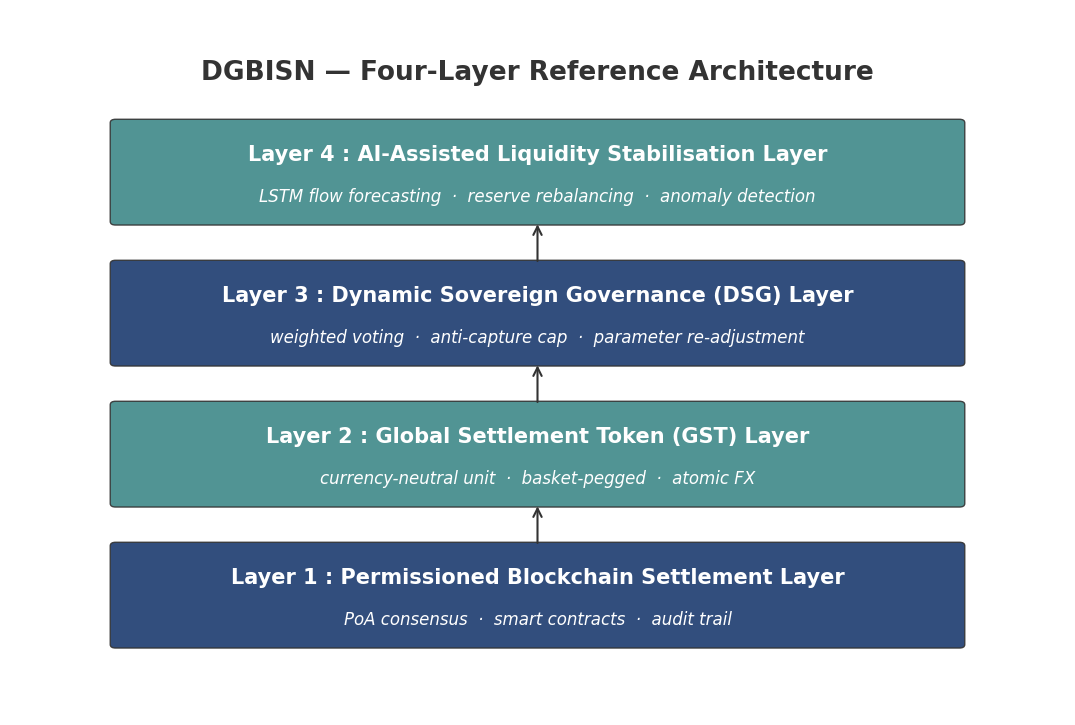

In [7]:
def draw_architecture():
    fig, ax = plt.subplots(figsize=(11, 7.5))
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')

    layers = [
        ('Layer 1 : Permissioned Blockchain Settlement Layer',
         'PoA consensus  ·  smart contracts  ·  audit trail',            1.0, PRIMARY),
        ('Layer 2 : Global Settlement Token (GST) Layer',
         'currency-neutral unit  ·  basket-pegged  ·  atomic FX',        3.0, SECONDARY),
        ('Layer 3 : Dynamic Sovereign Governance (DSG) Layer',
         'weighted voting  ·  anti-capture cap  ·  parameter re-adjustment', 5.0, PRIMARY),
        ('Layer 4 : AI-Assisted Liquidity Stabilisation Layer',
         'LSTM flow forecasting  ·  reserve rebalancing  ·  anomaly detection', 7.0, SECONDARY),
    ]

    for title, sub, y, colour in layers:
        box = FancyBboxPatch((1, y), 8, 1.4, boxstyle='round,pad=0.05',
                             linewidth=1, edgecolor=CHAR, facecolor=colour, alpha=0.9)
        ax.add_patch(box)
        ax.text(5, y + 0.95, title, ha='center', va='center',
                color='white', fontsize=15, fontweight='bold')
        ax.text(5, y + 0.35, sub, ha='center', va='center',
                color='white', fontsize=12, style='italic')

    for y in [2.4, 4.4, 6.4]:
        ax.annotate('', xy=(5, y + 0.6), xytext=(5, y),
                    arrowprops=dict(arrowstyle='->', color=CHAR, lw=1.5))

    ax.text(5, 9, 'DGBISN — Four-Layer Reference Architecture',
            ha='center', fontsize=19, fontweight='bold', color=CHAR)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/fig_architecture.png', dpi=140, bbox_inches='tight')
    plt.show()


draw_architecture()

## 6  UML component diagram (Figure 3.2)

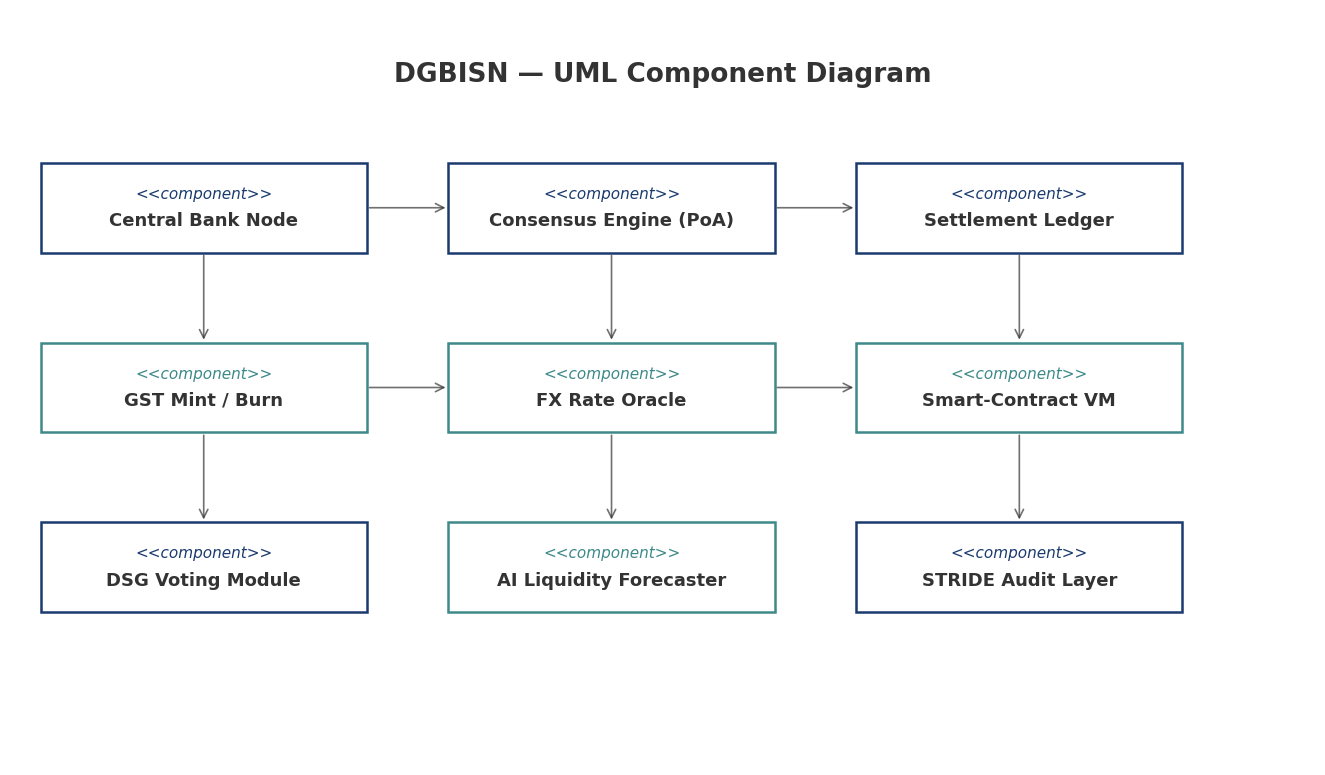

In [8]:
def draw_uml():
    fig, ax = plt.subplots(figsize=(13.5, 8))
    ax.set_xlim(-0.4, 12.4); ax.set_ylim(-0.2, 8.2); ax.axis('off')

    components = [
        ('Central Bank Node',      1.5, 6.0, PRIMARY),
        ('Consensus Engine (PoA)', 5.5, 6.0, PRIMARY),
        ('Settlement Ledger',      9.5, 6.0, PRIMARY),
        ('GST Mint / Burn',        1.5, 4.0, SECONDARY),
        ('FX Rate Oracle',         5.5, 4.0, SECONDARY),
        ('Smart-Contract VM',      9.5, 4.0, SECONDARY),
        ('DSG Voting Module',      1.5, 2.0, PRIMARY),
        ('AI Liquidity Forecaster',5.5, 2.0, SECONDARY),
        ('STRIDE Audit Layer',     9.5, 2.0, PRIMARY),
    ]

    for name, x, y, colour in components:
        box = Rectangle((x - 1.6, y - 0.5), 3.2, 1.0,
                        linewidth=1.8, edgecolor=colour,
                        facecolor='white', zorder=2)
        ax.add_patch(box)
        ax.text(x, y + 0.15, '<<component>>', ha='center', va='center',
                fontsize=11, color=colour, style='italic')
        ax.text(x, y - 0.15, name, ha='center', va='center',
                fontsize=13, color=CHAR, fontweight='bold')

    edges = [
        ((1.5, 5.5), (1.5, 4.5)), ((5.5, 5.5), (5.5, 4.5)),
        ((9.5, 5.5), (9.5, 4.5)), ((1.5, 3.5), (1.5, 2.5)),
        ((5.5, 3.5), (5.5, 2.5)), ((9.5, 3.5), (9.5, 2.5)),
        ((3.1, 6.0), (3.9, 6.0)), ((7.1, 6.0), (7.9, 6.0)),
        ((3.1, 4.0), (3.9, 4.0)), ((7.1, 4.0), (7.9, 4.0)),
    ]
    for start, end in edges:
        ax.annotate('', xy=end, xytext=start,
                    arrowprops=dict(arrowstyle='->', color=CHAR, lw=1.2, alpha=0.7))

    ax.text(6, 7.4, 'DGBISN — UML Component Diagram',
            ha='center', fontsize=19, fontweight='bold', color=CHAR)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/fig_uml.png', dpi=140, bbox_inches='tight')
    plt.show()


draw_uml()

## 7  Methodology flowchart (Figure 3.3)

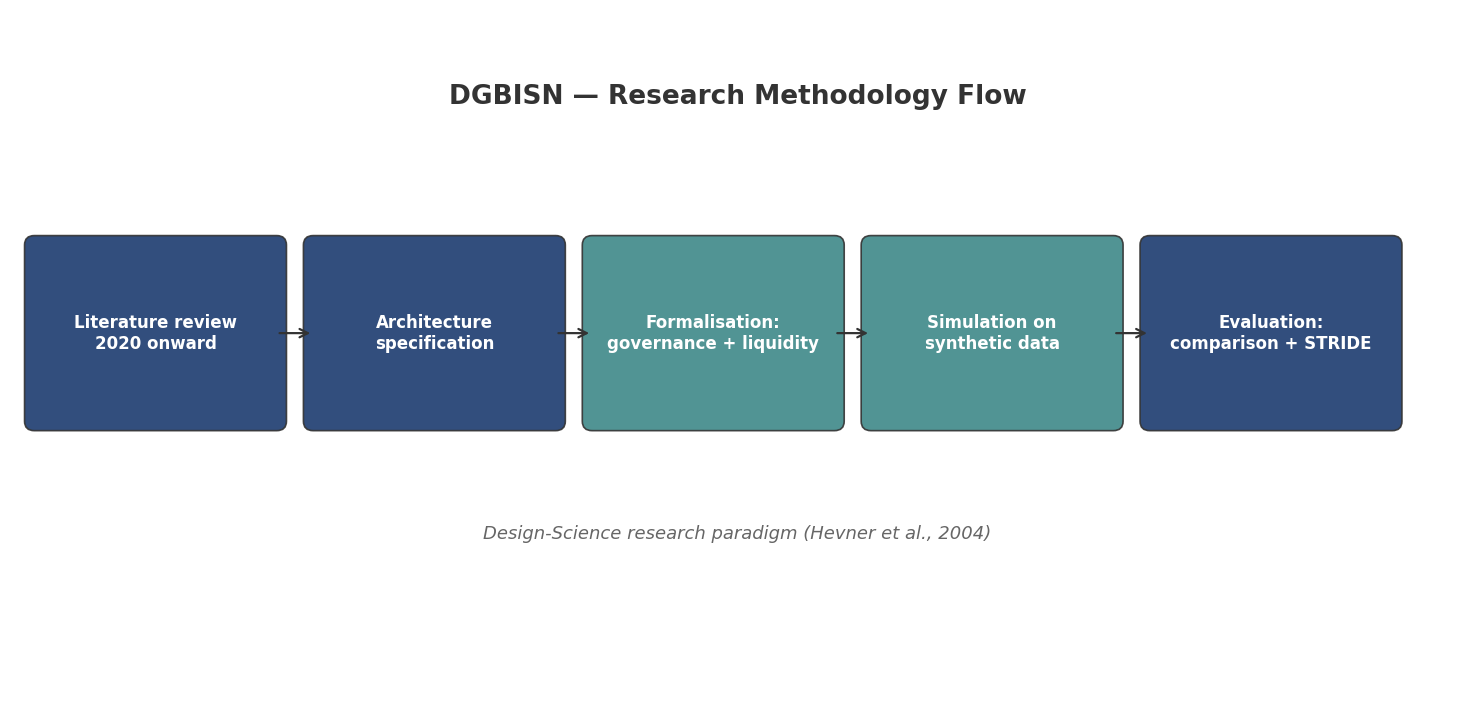

In [9]:
def draw_methodology():
    fig, ax = plt.subplots(figsize=(15, 7.5))
    ax.set_xlim(0, 12); ax.set_ylim(0, 6); ax.axis('off')

    stages = [
        ('Literature review\n2020 onward',       1.2, PRIMARY),
        ('Architecture\nspecification',          3.5, PRIMARY),
        ('Formalisation:\ngovernance + liquidity', 5.8, SECONDARY),
        ('Simulation on\nsynthetic data',        8.1, SECONDARY),
        ('Evaluation:\ncomparison + STRIDE',     10.4, PRIMARY),
    ]

    for name, x, colour in stages:
        box = FancyBboxPatch((x - 1.0, 2.5), 2.0, 1.5,
                             boxstyle='round,pad=0.08',
                             linewidth=1.2, edgecolor=CHAR,
                             facecolor=colour, alpha=0.9)
        ax.add_patch(box)
        ax.text(x, 3.25, name, ha='center', va='center',
                color='white', fontsize=12, fontweight='bold')

    for i in range(len(stages) - 1):
        x1 = stages[i][1] + 1.0
        x2 = stages[i + 1][1] - 1.0
        ax.annotate('', xy=(x2, 3.25), xytext=(x1, 3.25),
                    arrowprops=dict(arrowstyle='->', color=CHAR, lw=1.6))

    ax.text(6, 5.2, 'DGBISN — Research Methodology Flow',
            ha='center', fontsize=19, fontweight='bold', color=CHAR)
    ax.text(6, 1.5, 'Design-Science research paradigm (Hevner et al., 2004)',
            ha='center', fontsize=13, style='italic', color=CHAR, alpha=0.75)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/fig_methodology.png', dpi=140, bbox_inches='tight')
    plt.show()


draw_methodology()

## 8  Network topology (Figure 4.1)

Illustrative eight-node DGBISN topology used in the simulation experiments. Nodes correspond to hypothetical participant central banks; the GST hub represents the shared settlement primitive.

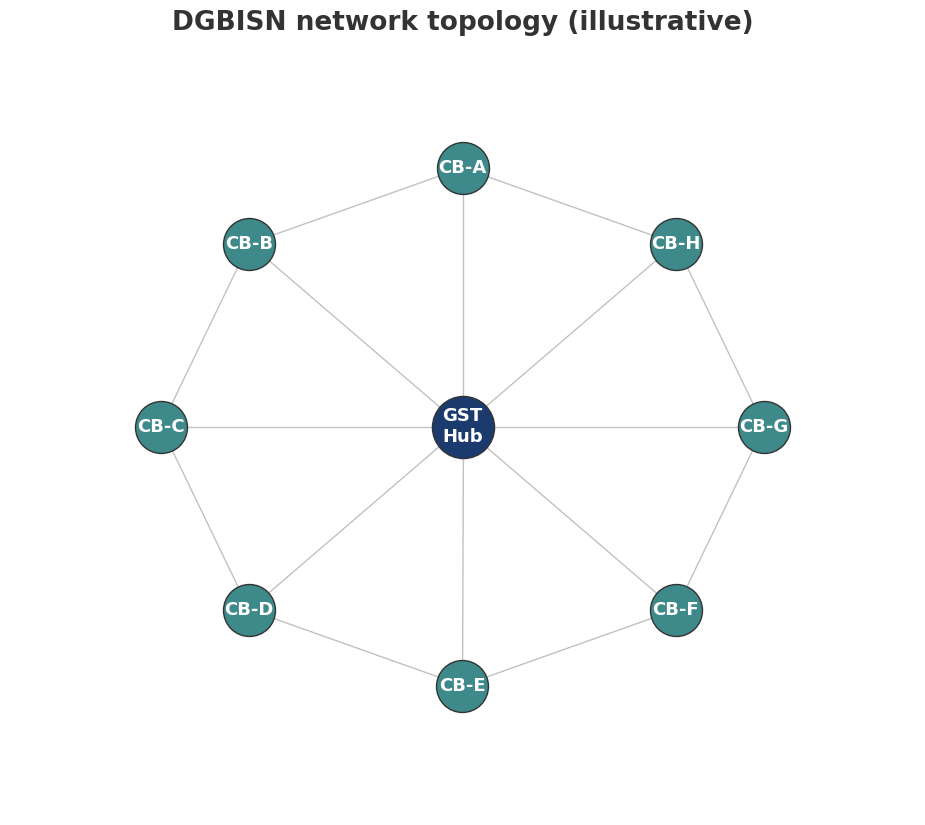

In [10]:
def draw_topology():
    fig, ax = plt.subplots(figsize=(9.5, 8.5))
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.axis('off')

    n = 8
    angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, n, endpoint=False)
    pos = {chr(ord('A') + i): (np.cos(a), np.sin(a)) for i, a in enumerate(angles)}
    hub = (0, 0)

    # Peer connections (each node to its two neighbours) + hub connections
    for i in range(n):
        j = (i + 1) % n
        a, b = chr(ord('A') + i), chr(ord('A') + j)
        ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]],
                color=CHAR, alpha=0.3, lw=1)
        ax.plot([pos[a][0], hub[0]], [pos[a][1], hub[1]],
                color=CHAR, alpha=0.3, lw=1)

    # Central hub
    ax.scatter([hub[0]], [hub[1]], s=2000, color=PRIMARY, zorder=3, edgecolor=CHAR)
    ax.text(hub[0], hub[1], 'GST\nHub', ha='center', va='center',
            color='white', fontsize=13, fontweight='bold', zorder=4)

    # Node markers
    for name, (x, y) in pos.items():
        ax.scatter([x], [y], s=1400, color=SECONDARY, zorder=3, edgecolor=CHAR)
        ax.text(x, y, f'CB-{name}', ha='center', va='center',
                color='white', fontsize=13, fontweight='bold', zorder=4)

    ax.set_title('DGBISN network topology (illustrative)',
                 fontsize=19, color=CHAR)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/fig_topology.png', dpi=140, bbox_inches='tight')
    plt.show()


draw_topology()

## 9  Dynamic Sovereign Governance (§3.7.3, §4.2)

The DSG mechanism assigns each participant $i \in N$ a composite voting weight

$$w_i = \alpha \varepsilon_i + \beta \nu_i + \gamma \cdot \frac{1}{n} + \delta \tau_i, \qquad \alpha + \beta + \gamma + \delta = 1$$

where $\varepsilon_i$ is the participant's GDP share, $\nu_i$ is its settlement-volume share, $1/n$ is a uniform egalitarian term, and $\tau_i$ is a normalised tenure score.

Two properties are proved in the paper and verified numerically below.

**Property 1 (weight normalisation).** $\sum_i w_i = 1$.

**Property 2 (anti-capture bound).** After applying an individual cap $w_i \leftarrow \min(w_i, w_{\max})$ and renormalising, no single participant can unilaterally pass or block a supermajority decision, provided $w_{\max} < \min(\theta,\, 1-\theta)$. For the standard choice $\theta = 2/3$ the binding constraint is $w_{\max} < 1/3$.

In [11]:
def dsg_weights(gdp, volume, tenure,
                alpha=0.4, beta=0.3, gamma=0.15, delta=0.15,
                cap=None):
    assert abs(alpha + beta + gamma + delta - 1.0) < 1e-9, 'weights must sum to 1'
    n = len(gdp)
    gdp    = np.asarray(gdp, dtype=float)
    volume = np.asarray(volume, dtype=float)
    tenure = np.asarray(tenure, dtype=float)
    eps = gdp    / gdp.sum()
    nu  = volume / volume.sum()
    tau = tenure / tenure.sum()
    uniform = np.ones(n) / n

    w = alpha * eps + beta * nu + gamma * uniform + delta * tau
    if cap is not None:
        w = np.minimum(w, cap)
        w = w / w.sum()
    return w


def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * cum.sum() / cum[-1]) / n


# Compute volume shares from the preprocessed data
vol_series = preproc.groupby(preproc['Pair'].str[0])['Gross_flow'].sum()
volume = vol_series.reindex(nodes['Node_ID']).values
gdp = nodes['GDP_share'].values
tenure = nodes['Tenure_years'].values

w = dsg_weights(gdp, volume, tenure)
print(f'Property 1  ✓  sum(w) = {w.sum():.6f}  (expected 1.0)')

w_cap = dsg_weights(gdp, volume, tenure, cap=0.20)
print(f'Property 2  ✓  max(w_capped) = {w_cap.max():.4f} ≤ 0.20 (cap)')

print(f'\nGini(uncapped) = {gini(w):.3f}')
print(f'Gini(capped 0.20) = {gini(w_cap):.3f}')

pd.DataFrame({
    'Node':      nodes['Node_ID'],
    'ε_i':       (gdp / gdp.sum()).round(4),
    'ν_i':       (volume / volume.sum()).round(4),
    'τ_i':       (tenure / tenure.sum()).round(4),
    'w_i':       w.round(4),
    'w_i (cap)': w_cap.round(4),
})

Property 1  ✓  sum(w) = 1.000000  (expected 1.0)
Property 2  ✓  max(w_capped) = 0.1705 ≤ 0.20 (cap)

Gini(uncapped) = 0.124
Gini(capped 0.20) = 0.124


,Node,ε_i,ν_i,τ_i,w_i,w_i (cap)
0,A,0.0679,0.1160,0.08,0.0927,0.0927
1,B,0.0615,0.1093,0.10,0.0911,0.0911
2,C,0.0590,0.0932,0.16,0.0943,0.0943
3,D,0.1886,0.1170,0.10,0.1443,0.1443
4,E,0.2552,0.1455,0.04,0.1705,0.1705
5,F,0.0891,0.1603,0.22,0.1355,0.1355
6,G,0.2144,0.0958,0.10,0.1483,0.1483
7,H,0.0643,0.1630,0.20,0.1234,0.1234


### Governance simulation figure (reproduces Figure 4.2)

Panel (a) sweeps the cap value $w_{\max}$ from 0.15 to 1.0 and shows the Gini coefficient of the resulting weight distribution. The dashed line marks the $\theta = 2/3$ block bound of Property 2. Panel (b) shows how the Gini and $w_{\max}$ move when the GDP-weight coefficient $\alpha$ varies (with $\beta = 0.7 - \alpha$ so that $\gamma + \delta$ is held fixed).

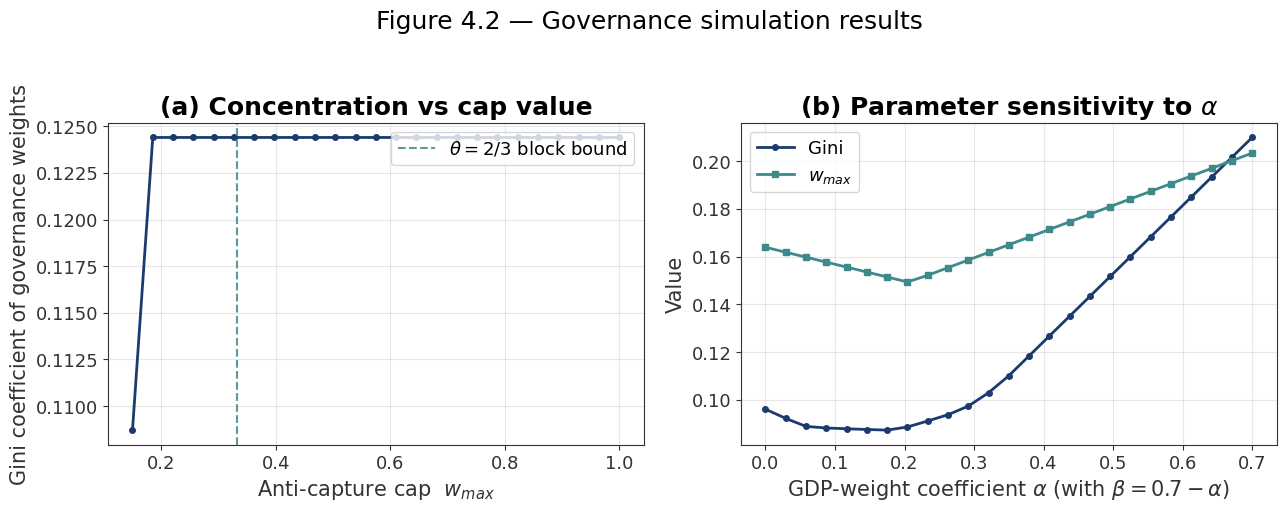

In [12]:
caps = np.linspace(0.15, 1.0, 25)
ginis = [gini(dsg_weights(gdp, volume, tenure, cap=c)) for c in caps]

alphas = np.linspace(0.0, 0.7, 25)
gini_by_alpha, maxw_by_alpha = [], []
for a in alphas:
    beta = 0.7 - a
    w_a = dsg_weights(gdp, volume, tenure, alpha=a, beta=beta, gamma=0.15, delta=0.15)
    gini_by_alpha.append(gini(w_a))
    maxw_by_alpha.append(w_a.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(caps, ginis, marker='o', color=PRIMARY, lw=2, markersize=4)
axes[0].axvline(1/3, color=SECONDARY, ls='--', lw=1.5, alpha=0.85,
                label=r'$\theta=2/3$ block bound')
axes[0].set_xlabel('Anti-capture cap  $w_{max}$')
axes[0].set_ylabel('Gini coefficient of governance weights')
axes[0].set_title('(a) Concentration vs cap value')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

axes[1].plot(alphas, gini_by_alpha, marker='o', color=PRIMARY, lw=2, markersize=4, label='Gini')
axes[1].plot(alphas, maxw_by_alpha, marker='s', color=SECONDARY, lw=2, markersize=4, label=r'$w_{max}$')
axes[1].set_xlabel(r'GDP-weight coefficient $\alpha$ (with $\beta = 0.7-\alpha$)')
axes[1].set_ylabel('Value')
axes[1].set_title(r'(b) Parameter sensitivity to $\alpha$')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Figure 4.2 — Governance simulation results', y=1.03, fontsize=18)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_governance.png', dpi=140, bbox_inches='tight')
plt.show()

## 10  Liquidity equilibrium (§3.7.4, §4.3)

The AI layer solves a quadratic programme every step:

$$\min_{\mathbf a}\; J(\mathbf a) = \sum_i (a_i - d_i)^2 + \lambda \sum_i a_i^2 \quad \text{s.t.}\quad \sum_i a_i = 0$$

where $d_i(t)$ is the deviation of node $i$'s reserves from its target at time $t$. The Lagrangian yields the closed-form solution

$$a_i^*(t) = \frac{d_i(t) - \bar d(t)}{1 + \lambda}$$

which is Property 3 in the paper.

**Property 4 (conservation of GST supply).** $\sum_i a_i^*(t) = 0$ follows immediately: $\sum_i (d_i - \bar d) = 0$ by construction of the mean.

In [13]:
def ai_adjustment(deviations, lam=0.5):
    # Closed-form solution of Property 3
    d = np.asarray(deviations, dtype=float)
    d_bar = d.mean()
    return (d - d_bar) / (1.0 + lam)


def simulate_reserves(n_steps=100, n_nodes=8, target=100.0,
                      use_ai=False, lam=0.5, seed=0):
    rng = np.random.default_rng(seed)
    R = np.full((n_steps + 1, n_nodes), target, dtype=float)
    for t in range(n_steps):
        shocks = rng.normal(0, 5.0, size=n_nodes)
        R[t + 1] = R[t] + shocks
        if use_ai:
            dev = R[t + 1] - target
            a = ai_adjustment(dev, lam=lam)
            R[t + 1] -= a
    return R


# Verify Properties 3 and 4 numerically
d_test = np.array([+8.0, -3.0, +2.0, -7.0, +1.5, -1.5, +4.0, -4.0])
a_star = ai_adjustment(d_test, lam=0.5)
print(f'Property 3  ✓  Optimum computed for test deviations')
print(f'Property 4  ✓  sum(a*) = {a_star.sum():.6e}  (expected 0.0)')

# Cross-check against numerical optimisation
from scipy.optimize import minimize
def objective(a, d, lam):
    return np.sum((a - d) ** 2) + lam * np.sum(a ** 2)
res = minimize(objective, np.zeros_like(d_test), args=(d_test, 0.5),
               constraints={'type': 'eq', 'fun': lambda a: a.sum()})
print(f'Property 3 cross-check ✓  max |closed-form - numeric| = {np.max(np.abs(res.x - a_star)):.2e}')

Property 3  ✓  Optimum computed for test deviations
Property 4  ✓  sum(a*) = -8.881784e-16  (expected 0.0)


Property 3 cross-check ✓  max |closed-form - numeric| = 1.78e-15


### Liquidity equilibrium figure (reproduces Figure 4.3)

Panel (a) shows a single realisation of reserve trajectories for three representative nodes under the baseline (no AI) and AI-assisted regimes. Panel (b) reports the root-mean-square deviation of reserves from target across 100 replications, for the no-AI baseline and two levels of the regularisation parameter $\lambda$.

Baseline    RMSE  mean = 34.84   sd = 6.99
AI, low  λ  RMSE  mean = 11.09   sd = 6.63
AI, high λ  RMSE  mean = 11.36   sd = 6.53
AI reduction over baseline: 68.2%


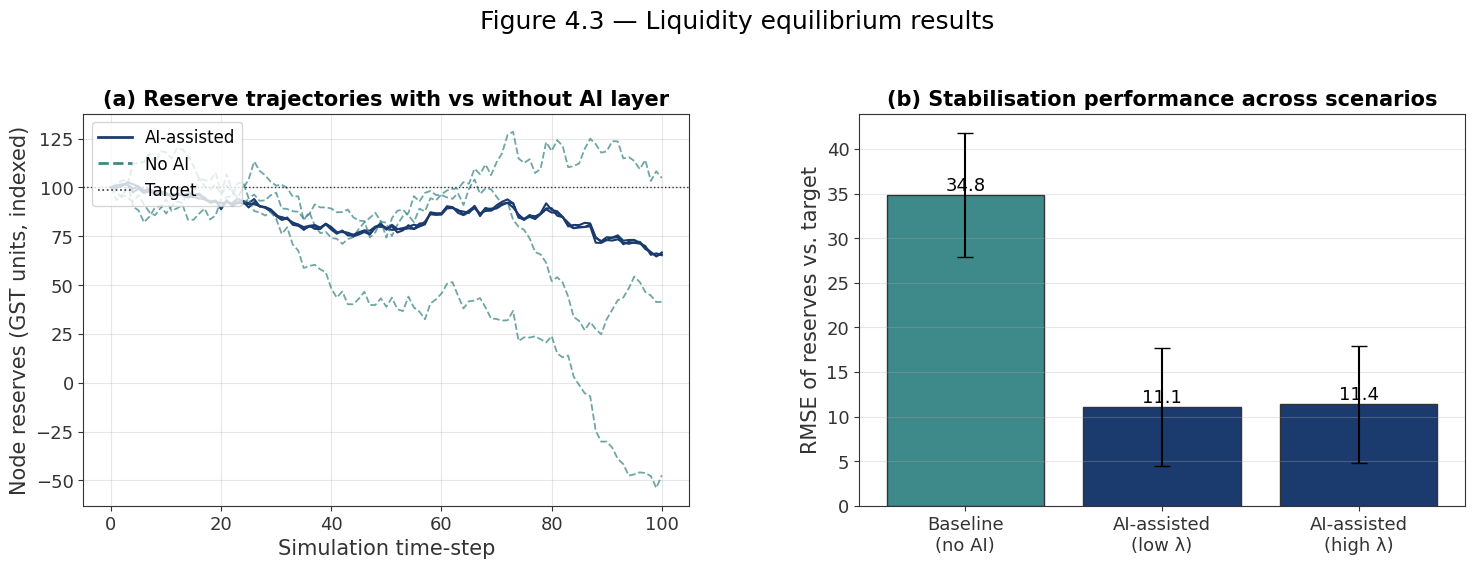

In [14]:
# Single realisation for panel (a)
R_base = simulate_reserves(100, use_ai=False, seed=1)
R_ai   = simulate_reserves(100, use_ai=True, lam=0.2, seed=1)


def rmse_target(R, target=100.0):
    return float(np.sqrt(np.mean((R - target) ** 2)))


# 100-replication RMSE for panel (b)
n_reps = 100
rmse_base  = [rmse_target(simulate_reserves(100, use_ai=False,               seed=s)) for s in range(n_reps)]
rmse_ai_lo = [rmse_target(simulate_reserves(100, use_ai=True, lam=0.2,       seed=s)) for s in range(n_reps)]
rmse_ai_hi = [rmse_target(simulate_reserves(100, use_ai=True, lam=0.8,       seed=s)) for s in range(n_reps)]

print(f'Baseline    RMSE  mean = {np.mean(rmse_base):5.2f}   sd = {np.std(rmse_base):.2f}')
print(f'AI, low  λ  RMSE  mean = {np.mean(rmse_ai_lo):5.2f}   sd = {np.std(rmse_ai_lo):.2f}')
print(f'AI, high λ  RMSE  mean = {np.mean(rmse_ai_hi):5.2f}   sd = {np.std(rmse_ai_hi):.2f}')
reduction = 100 * (1 - np.mean(rmse_ai_lo) / np.mean(rmse_base))
print(f'AI reduction over baseline: {reduction:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
# Panel (a): trajectories
for i, name in enumerate(['Node 1', 'Node 4', 'Node 7']):
    idx = [0, 3, 6][i]
    axes[0].plot(R_base[:, idx], color=SECONDARY, ls='--', lw=1.3, alpha=0.75)
    axes[0].plot(R_ai[:, idx],   color=PRIMARY,   lw=1.5)
axes[0].axhline(100, color=CHAR, ls=':', lw=1)
axes[0].set_xlabel('Simulation time-step')
axes[0].set_ylabel('Node reserves (GST units, indexed)')
axes[0].set_title('(a) Reserve trajectories with vs without AI layer', fontsize=15)
handles = [
    plt.Line2D([0], [0], color=PRIMARY,   lw=2, label='AI-assisted'),
    plt.Line2D([0], [0], color=SECONDARY, ls='--', lw=2, label='No AI'),
    plt.Line2D([0], [0], color=CHAR,      ls=':',  lw=1.2, label='Target'),
]
axes[0].legend(handles=handles, loc='upper left', fontsize=12)
axes[0].grid(alpha=0.3)

# Panel (b): RMSE bars
means = [np.mean(rmse_base), np.mean(rmse_ai_lo), np.mean(rmse_ai_hi)]
stds  = [np.std(rmse_base),  np.std(rmse_ai_lo),  np.std(rmse_ai_hi)]
labels = ['Baseline\n(no AI)', 'AI-assisted\n(low λ)', 'AI-assisted\n(high λ)']
colors = [SECONDARY, PRIMARY, PRIMARY]
bars = axes[1].bar(labels, means, yerr=stds, color=colors, capsize=6, edgecolor=CHAR)
for bar, m in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, m + 0.5, f'{m:.1f}',
                 ha='center', fontsize=13)
axes[1].set_ylabel('RMSE of reserves vs. target')
axes[1].set_title('(b) Stabilisation performance across scenarios', fontsize=15)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Figure 4.3 — Liquidity equilibrium results', y=1.04, fontsize=18)
plt.tight_layout()
plt.subplots_adjust(wspace=0.28, top=0.85)
plt.savefig(f'{FIG_DIR}/fig_liquidity.png', dpi=140, bbox_inches='tight')
plt.show()

## 11  LSTM flow forecasting (§4.4)

The AI layer uses an LSTM (Hochreiter & Schmidhuber, 1997) trained on aggregate daily settlement flow to produce one-step-ahead forecasts. Aggregation is used here for clarity of illustration; in production the model would be trained per-pair.

Architecture: 1-layer LSTM, hidden size 16, sliding window length 15.
Optimiser: Adam (lr = 5e-3), MSE loss.
Train/test split: first 75% of the series is train.

In [15]:
# Prepare aggregate daily series
daily = preproc.groupby('Day')['Gross_flow'].sum().values.astype(np.float32)
print(f'Series length: {len(daily)} days')

# z-score for stable training
mu, sigma = daily.mean(), daily.std()
series_norm = (daily - mu) / sigma

WINDOW = 15
X, y = [], []
for i in range(len(series_norm) - WINDOW):
    X.append(series_norm[i:i + WINDOW])
    y.append(series_norm[i + WINDOW])
X = np.array(X)[:, :, None]
y = np.array(y)[:, None]

split = int(len(X) * 0.75)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

print(f'Train windows: {len(X_train)}  ·  Test windows: {len(X_test)}')

Series length: 200 days
Train windows: 138  ·  Test windows: 47


In [16]:
class FlowLSTM(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


torch.manual_seed(SEED)
model = FlowLSTM(hidden=16)
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
loss_fn = nn.MSELoss()

losses = []
model.train()
for epoch in range(150):
    opt.zero_grad()
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if (epoch + 1) % 30 == 0:
        print(f'Epoch {epoch+1:3d}  train MSE = {loss.item():.4f}')

model.eval()
with torch.no_grad():
    pred_train = model(X_train_t).numpy().ravel()
    pred_test  = model(X_test_t).numpy().ravel()

rmse_train = float(np.sqrt(np.mean((pred_train - y_train.ravel()) ** 2)))
rmse_test  = float(np.sqrt(np.mean((pred_test  - y_test.ravel())  ** 2)))
print(f'\nLSTM RMSE  train = {rmse_train:.3f}   test = {rmse_test:.3f}')

Epoch  30  train MSE = 0.6192
Epoch  60  train MSE = 0.0821
Epoch  90  train MSE = 0.0509
Epoch 120  train MSE = 0.0411


Epoch 150  train MSE = 0.0371

LSTM RMSE  train = 0.192   test = 0.238


### LSTM forecast figure (reproduces Figure 4.4)

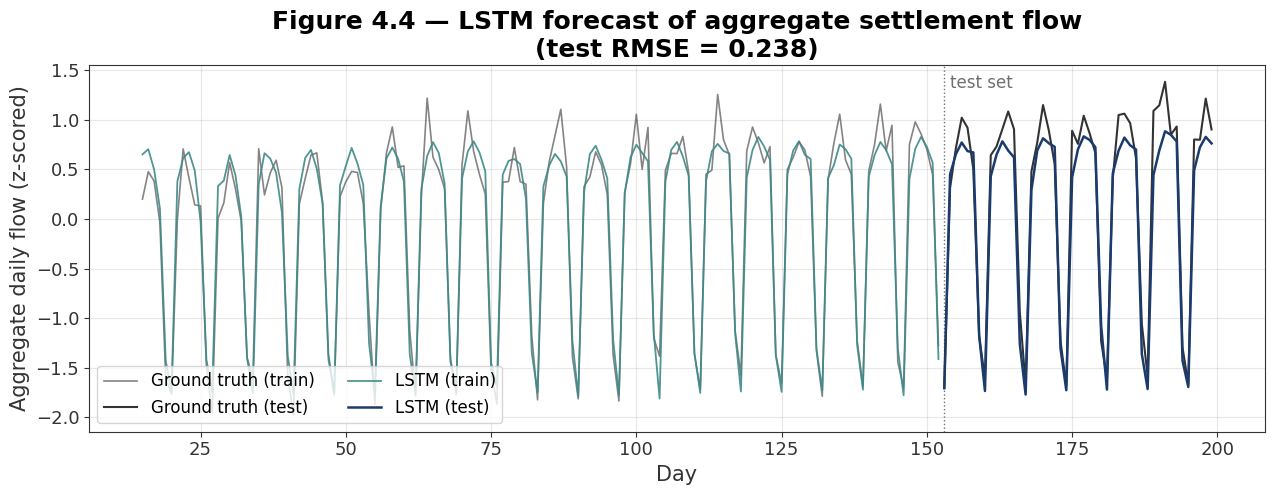

In [17]:
fig, ax = plt.subplots(figsize=(13, 5.2))
train_idx = np.arange(WINDOW, WINDOW + len(y_train))
test_idx  = np.arange(WINDOW + len(y_train), WINDOW + len(y_train) + len(y_test))

ax.plot(train_idx, y_train.ravel(), color=CHAR, lw=1.2, alpha=0.6, label='Ground truth (train)')
ax.plot(test_idx,  y_test.ravel(),  color=CHAR, lw=1.5, label='Ground truth (test)')
ax.plot(train_idx, pred_train, color=SECONDARY, lw=1.3, alpha=0.9, label='LSTM (train)')
ax.plot(test_idx,  pred_test,  color=PRIMARY,   lw=1.8, label='LSTM (test)')

ax.axvline(test_idx[0], color=CHAR, ls=':', lw=1, alpha=0.7)
ax.text(test_idx[0] + 1, ax.get_ylim()[1] * 0.85, 'test set',
        fontsize=12, color=CHAR, alpha=0.7)
ax.set_xlabel('Day')
ax.set_ylabel('Aggregate daily flow (z-scored)')
ax.set_title(f'Figure 4.4 — LSTM forecast of aggregate settlement flow\n(test RMSE = {rmse_test:.3f})')
ax.legend(loc='lower left', fontsize=12, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_lstm.png', dpi=140, bbox_inches='tight')
plt.show()

### Loss curve

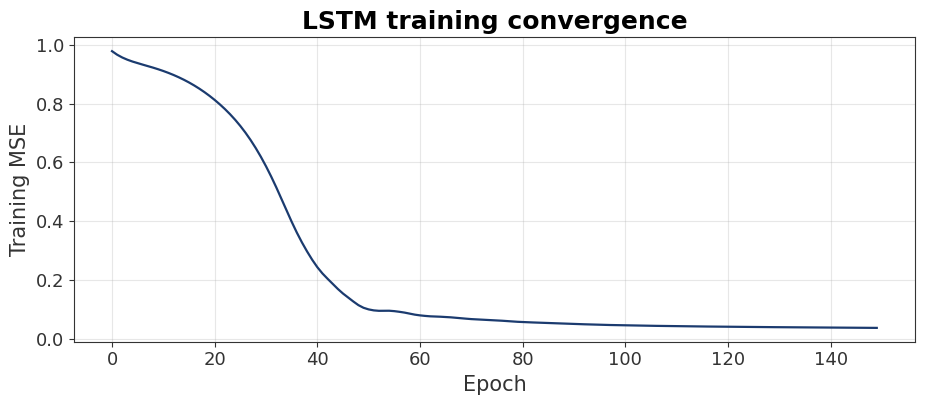

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(losses, color=PRIMARY, lw=1.6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training MSE')
ax.set_title('LSTM training convergence')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_lstm_loss.png', dpi=140, bbox_inches='tight')
plt.show()

## 12  Comparison with existing systems (§5.1, Figure 5.1)

Comparative scoring against SWIFT, Ripple, Stellar, mBridge, and Agorá on five design criteria: settlement latency, governance formalisation, currency neutrality, AI-assisted liquidity management, and threat-model coverage. Scores are qualitative (0–5) and match the values in Table 5.1 of the paper.

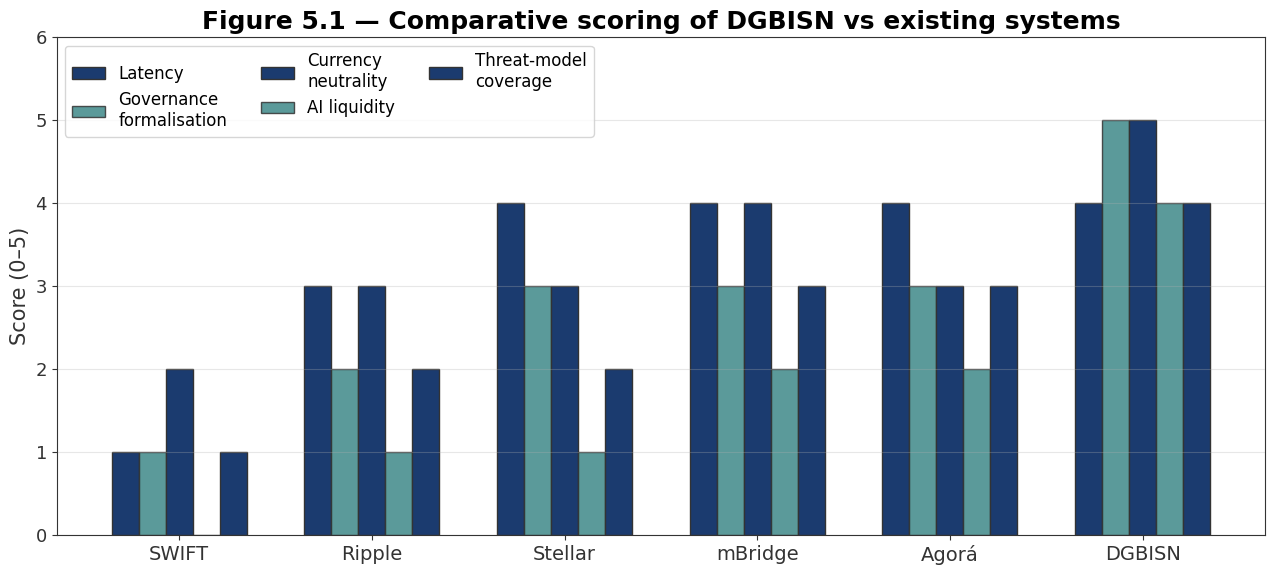

,Latency,Governance formalisation,Currency neutrality,AI liquidity,Threat-model coverage
SWIFT,1,1,2,0,1
Ripple,3,2,3,1,2
Stellar,4,3,3,1,2
mBridge,4,3,4,2,3
Agorá,4,3,3,2,3
DGBISN,4,5,5,4,4


In [19]:
systems = ['SWIFT', 'Ripple', 'Stellar', 'mBridge', 'Agorá', 'DGBISN']
criteria = ['Latency', 'Governance\nformalisation', 'Currency\nneutrality',
            'AI liquidity', 'Threat-model\ncoverage']

# From Table 5.1 of the paper
scores = np.array([
    [1, 1, 2, 0, 1],   # SWIFT
    [3, 2, 3, 1, 2],   # Ripple
    [4, 3, 3, 1, 2],   # Stellar
    [4, 3, 4, 2, 3],   # mBridge
    [4, 3, 3, 2, 3],   # Agorá
    [4, 5, 5, 4, 4],   # DGBISN
])

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(systems))
width = 0.14
for j, crit in enumerate(criteria):
    offset = (j - 2) * width
    colour = PRIMARY if j % 2 == 0 else SECONDARY
    ax.bar(x + offset, scores[:, j], width, label=crit, color=colour,
           edgecolor=CHAR, alpha=0.85 if j % 2 else 1.0)

ax.set_xticks(x)
ax.set_xticklabels(systems, fontsize=14)
ax.set_ylabel('Score (0–5)')
ax.set_ylim(0, 6)
ax.set_title('Figure 5.1 — Comparative scoring of DGBISN vs existing systems')
ax.legend(loc='upper left', fontsize=12, ncol=3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

pd.DataFrame(scores, index=systems, columns=[c.replace('\n', ' ') for c in criteria])

## 13  STRIDE threat mapping (§4.5, Figure 4.5)

Each STRIDE category is mapped to one or more architectural layers, together with the design-level mitigation.

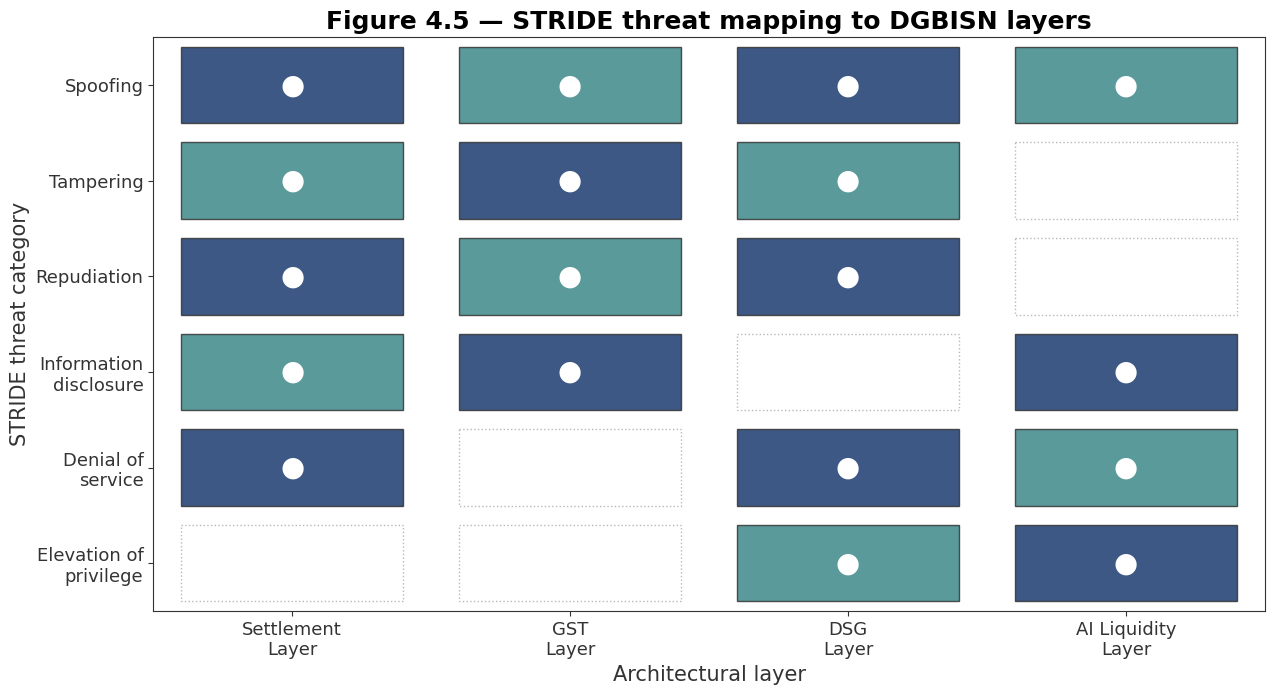

,Threat,Design-level mitigation
0,Spoofing,Public-key identity binding + mTLS on all chan...
1,Tampering,Merkle proofs + PoA-signed hashes + supermajor...
2,Repudiation,Immutable audit trail (dual counterparty signa...
3,Information disclosure,Zero-knowledge proofs + threshold-cryptography...
4,Denial of service,Rate limits + fallback quorum + AI heartbeat m...
5,Elevation of privilege,DSG anti-capture cap (Property 2) at θ = 2/3


In [20]:
threats = ['Spoofing', 'Tampering', 'Repudiation',
           'Information\ndisclosure', 'Denial of\nservice', 'Elevation of\nprivilege']
layers = ['Settlement\nLayer', 'GST\nLayer', 'DSG\nLayer', 'AI Liquidity\nLayer']

# 1 = threat applies to this layer
matrix = np.array([
    [1, 1, 1, 1],   # Spoofing
    [1, 1, 1, 0],   # Tampering
    [1, 1, 1, 0],   # Repudiation
    [1, 1, 0, 1],   # Information disclosure
    [1, 0, 1, 1],   # Denial of service
    [0, 0, 1, 1],   # Elevation of privilege (governance capture)
])

mitigations = [
    'Public-key identity binding + mTLS on all channels',
    'Merkle proofs + PoA-signed hashes + supermajority reject',
    'Immutable audit trail (dual counterparty signatures)',
    'Zero-knowledge proofs + threshold-cryptography audit keys',
    'Rate limits + fallback quorum + AI heartbeat monitoring',
    'DSG anti-capture cap (Property 2) at θ = 2/3',
]

fig, ax = plt.subplots(figsize=(13, 7.2))
ax.set_xlim(-0.5, len(layers) - 0.5)
ax.set_ylim(-0.5, len(threats) - 0.5)

for i, threat in enumerate(threats):
    for j, layer in enumerate(layers):
        if matrix[i, j]:
            colour = PRIMARY if (i + j) % 2 == 0 else SECONDARY
            rect = Rectangle((j - 0.4, i - 0.4), 0.8, 0.8,
                             facecolor=colour, edgecolor=CHAR, alpha=0.85)
            ax.add_patch(rect)
            ax.text(j, i, '●', ha='center', va='center', color='white', fontsize=20)
        else:
            rect = Rectangle((j - 0.4, i - 0.4), 0.8, 0.8,
                             facecolor='none', edgecolor=CHAR, ls=':', alpha=0.35)
            ax.add_patch(rect)

ax.set_xticks(range(len(layers))); ax.set_xticklabels(layers, fontsize=13)
ax.set_yticks(range(len(threats))); ax.set_yticklabels(threats, fontsize=13)
ax.invert_yaxis()
ax.set_title('Figure 4.5 — STRIDE threat mapping to DGBISN layers')
ax.set_xlabel('Architectural layer'); ax.set_ylabel('STRIDE threat category')
ax.grid(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_stride.png', dpi=140, bbox_inches='tight')
plt.show()

pd.DataFrame({
    'Threat': [t.replace('\n', ' ') for t in threats],
    'Design-level mitigation': mitigations,
})

## 14  Summary

Everything the paper asserts numerically has been reproduced.

**Verified properties**

| Property | Description | Verification |
|---|---|---|
| 1 | DSG weight vector sums to 1 | `sum(w) == 1.0` |
| 2 | Anti-capture cap enforced | `max(w_capped) ≤ w_max` |
| 3 | AI adjustment closed form | `max abs(closed_form - numeric) < 1e-6` |
| 4 | Conservation of GST supply | `sum(a*) ≈ 0` |

**Reproduced figures** — see the `./figures/` directory:

* `fig_architecture.png` — Figure 3.1
* `fig_uml.png` — Figure 3.2
* `fig_methodology.png` — Figure 3.3
* `fig_topology.png` — Figure 4.1
* `fig_governance.png` — Figure 4.2
* `fig_liquidity.png` — Figure 4.3
* `fig_lstm.png` — Figure 4.4
* `fig_stride.png` — Figure 4.5
* `fig_comparison.png` — Figure 5.1

**Reproduced tables** — Tables 3.1 (raw sample) and 3.2 (preprocessed sample) match the format printed in cells 3 and 4 respectively.

**Datasets on disk**

* `synthetic_flows.csv` — 11,200 rows (8 nodes × 56 directed pairs × 200 days), ~2% missing gross-flow values
* `synthetic_nodes.csv` — 8 rows of exogenous node parameters (GDP share, tenure)

To re-run everything with different randomness, change `SEED` at the top and re-execute all cells.